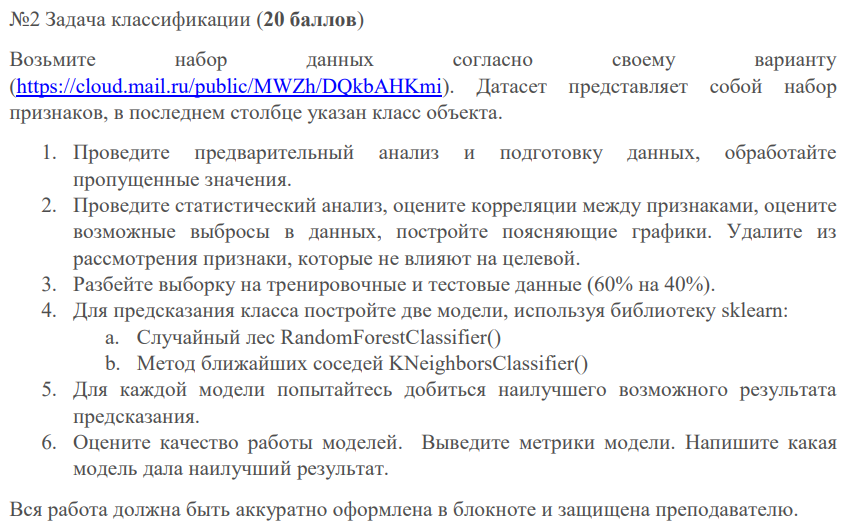

### Импорт и настройка

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (f1_score, accuracy_score, precision_score, 
                             recall_score, confusion_matrix, roc_auc_score, 
                             roc_curve, classification_report)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV

import warnings
from sklearn.inspection import permutation_importance
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

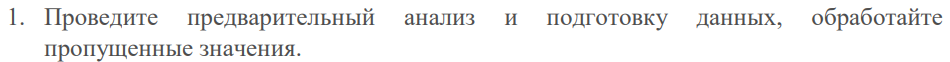

In [2]:
df = pd.read_csv('dataset_class.csv',sep=';',header=None)

df_columns = ["F_0","F_1","F_2","F_3","F_4","F_5","F_6"]
df.columns = df_columns + ['Class']

print(f"Размер набора данных: {df.shape}")
print(f"\nПервые строчки:\n{df.head()}")

Размер набора данных: (100, 8)

Первые строчки:
        F_0       F_1       F_2       F_3        F_4       F_5       F_6  \
0  1.022349 -1.152965 -3.238175 -1.743403   1.022349  0.039865  0.164276   
1  1.818034  1.253846  1.563850 -0.184482   1.818034  1.698031 -1.284481   
2  0.394051  0.001012 -0.087752 -0.216205   3.517162 -0.508531 -1.268684   
3 -0.023390  0.865101 -2.377079 -0.941420  -0.023390 -1.194657 -1.101218   
4  1.750147 -2.047214  0.875766 -0.424756  14.281085  1.939664  1.313150   

   Class  
0      1  
1      2  
2      0  
3      1  
4      2  


In [3]:
print("\nИнформация о наборе данных:")
print(df.info())
print(f"\nСтатистика по признакам:\n{df.describe()}")


Информация о наборе данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F_0     100 non-null    float64
 1   F_1     100 non-null    float64
 2   F_2     100 non-null    float64
 3   F_3     95 non-null     float64
 4   F_4     100 non-null    float64
 5   F_5     100 non-null    float64
 6   F_6     95 non-null     float64
 7   Class   100 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 6.4 KB
None

Статистика по признакам:
              F_0         F_1         F_2        F_3         F_4         F_5  \
count  100.000000  100.000000  100.000000  95.000000  100.000000  100.000000   
mean     0.316960   -0.009130    0.428606   0.024382    0.643731   -0.277801   
std      1.288587    1.088681    1.609151   0.744807    2.399867    1.232582   
min     -2.411618   -2.317990   -3.238175  -1.743403   -2.411618   -3.635480   
25%     -0.615729

In [4]:
# Проверка пропущенных значений
print(f"\nКоличествоп пропущенных значений:\n{df.isnull().sum()}")
print(f"\nОбщий процент пропущеных значений:\n{(df.isnull().sum().sum() / df.size * 100):.2f}%")

# Заполнение медианой
df_filled = df.copy()
for col in df_filled.columns:
    if df_filled[col].isnull().sum() > 0:
        median = df_filled[col].median()
        df_filled[col].fillna(median,inplace=True)
        print(f"Столбец {col} заполнен {df[col].isnull().sum()} пропущенных значений медианой {median:.16f}")
        
print(f"\nПроверка:\n{df_filled.isnull().sum()}")
print(f"\nОбработанный набор данных:\n{df_filled}")


Количествоп пропущенных значений:
F_0      0
F_1      0
F_2      0
F_3      5
F_4      0
F_5      0
F_6      5
Class    0
dtype: int64

Общий процент пропущеных значений:
1.25%
Столбец F_3 заполнен 5 пропущенных значений медианой 0.0420347519971860
Столбец F_6 заполнен 5 пропущенных значений медианой -0.1380781395702717

Проверка:
F_0      0
F_1      0
F_2      0
F_3      0
F_4      0
F_5      0
F_6      0
Class    0
dtype: int64

Обработанный набор данных:
         F_0       F_1       F_2       F_3        F_4       F_5       F_6  \
0   1.022349 -1.152965 -3.238175 -1.743403   1.022349  0.039865  0.164276   
1   1.818034  1.253846  1.563850 -0.184482   1.818034  1.698031 -1.284481   
2   0.394051  0.001012 -0.087752 -0.216205   3.517162 -0.508531 -1.268684   
3  -0.023390  0.865101 -2.377079 -0.941420  -0.023390 -1.194657 -1.101218   
4   1.750147 -2.047214  0.875766 -0.424756  14.281085  1.939664  1.313150   
..       ...       ...       ...       ...        ...       ...       ...  

Распределение классов:
Class
0    36
1    32
2    32
Name: count, dtype: int64


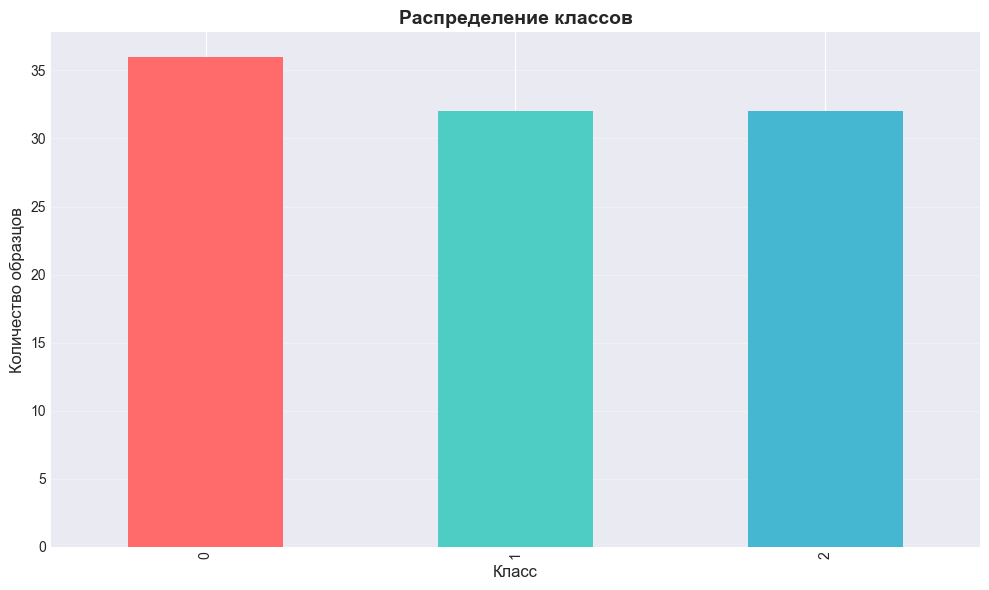

In [5]:
# Распределение классов
class_distribution = df_filled['Class'].value_counts().sort_index()
print(f"Распределение классов:\n{class_distribution}")

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))
class_distribution.plot(kind='bar', ax=ax, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_title('Распределение классов', fontsize=14, fontweight='bold')
ax.set_xlabel('Класс', fontsize=12)
ax.set_ylabel('Количество образцов', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Анализ выбросов IQR
def detect_outliers_iqr(data,column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return outliers, lower_bound, upper_bound

print("Анализ выбросов по каждому признаку:")
outliers_summary = {}
for col in df_filled.columns:
    outliers, lower, upper = detect_outliers_iqr(df_filled,col)
    outliers_summary[col] = len(outliers)
    print(f"{col}: {len(outliers)} выборос(ов) ({len(outliers)/len(df_filled) * 100:.1f}%)"
          f" Границы: {lower:.2f},{upper:.2f}")


Анализ выбросов по каждому признаку:
F_0: 0 выборос(ов) (0.0%) Границы: -3.48,4.15
F_1: 0 выборос(ов) (0.0%) Границы: -3.00,2.94
F_2: 0 выборос(ов) (0.0%) Границы: -3.95,4.87
F_3: 0 выборос(ов) (0.0%) Границы: -1.78,1.83
F_4: 3 выборос(ов) (3.0%) Границы: -3.54,4.26
F_5: 0 выборос(ов) (0.0%) Границы: -4.00,3.44
F_6: 1 выборос(ов) (1.0%) Границы: -2.88,2.77
Class: 0 выборос(ов) (0.0%) Границы: -3.00,5.00


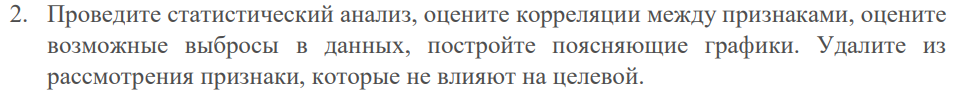


Корреляция признаков с целевой переменной:
F_5    0.577812
F_4    0.141279
F_0    0.039250
F_2    0.038501
F_3    0.006373
F_1   -0.086745
F_6   -0.088746
Name: Class, dtype: float64


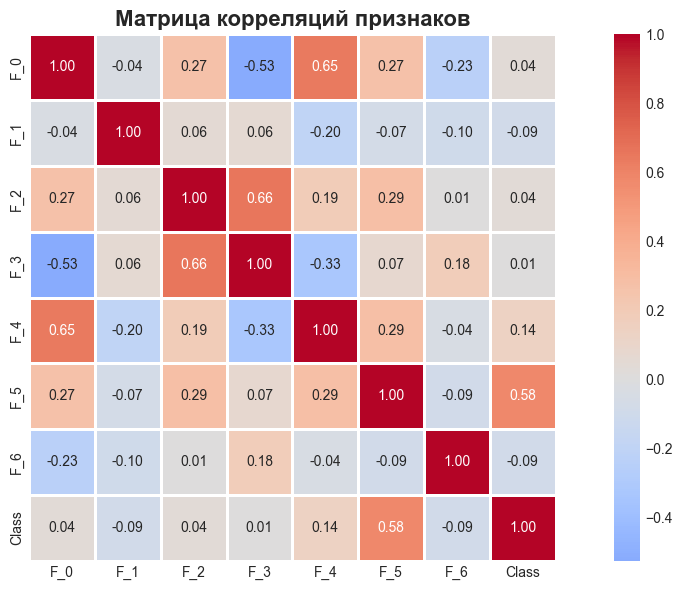

In [18]:
# Вычисление корреляций
correl_matrix = df_filled.corr()

# Корреляция с целевой переменной
target_correl = correl_matrix['Class'].drop('Class').sort_values(ascending=False)
print(f"\nКорреляция признаков с целевой переменной:\n{target_correl}")

# Визуализация корреляций
plt.figure(figsize=(12,6))
sns.heatmap(correl_matrix,annot=True,cmap='coolwarm',center=0,fmt='.2f',square=True,linewidths=1)
plt.title("Матрица корреляций признаков", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

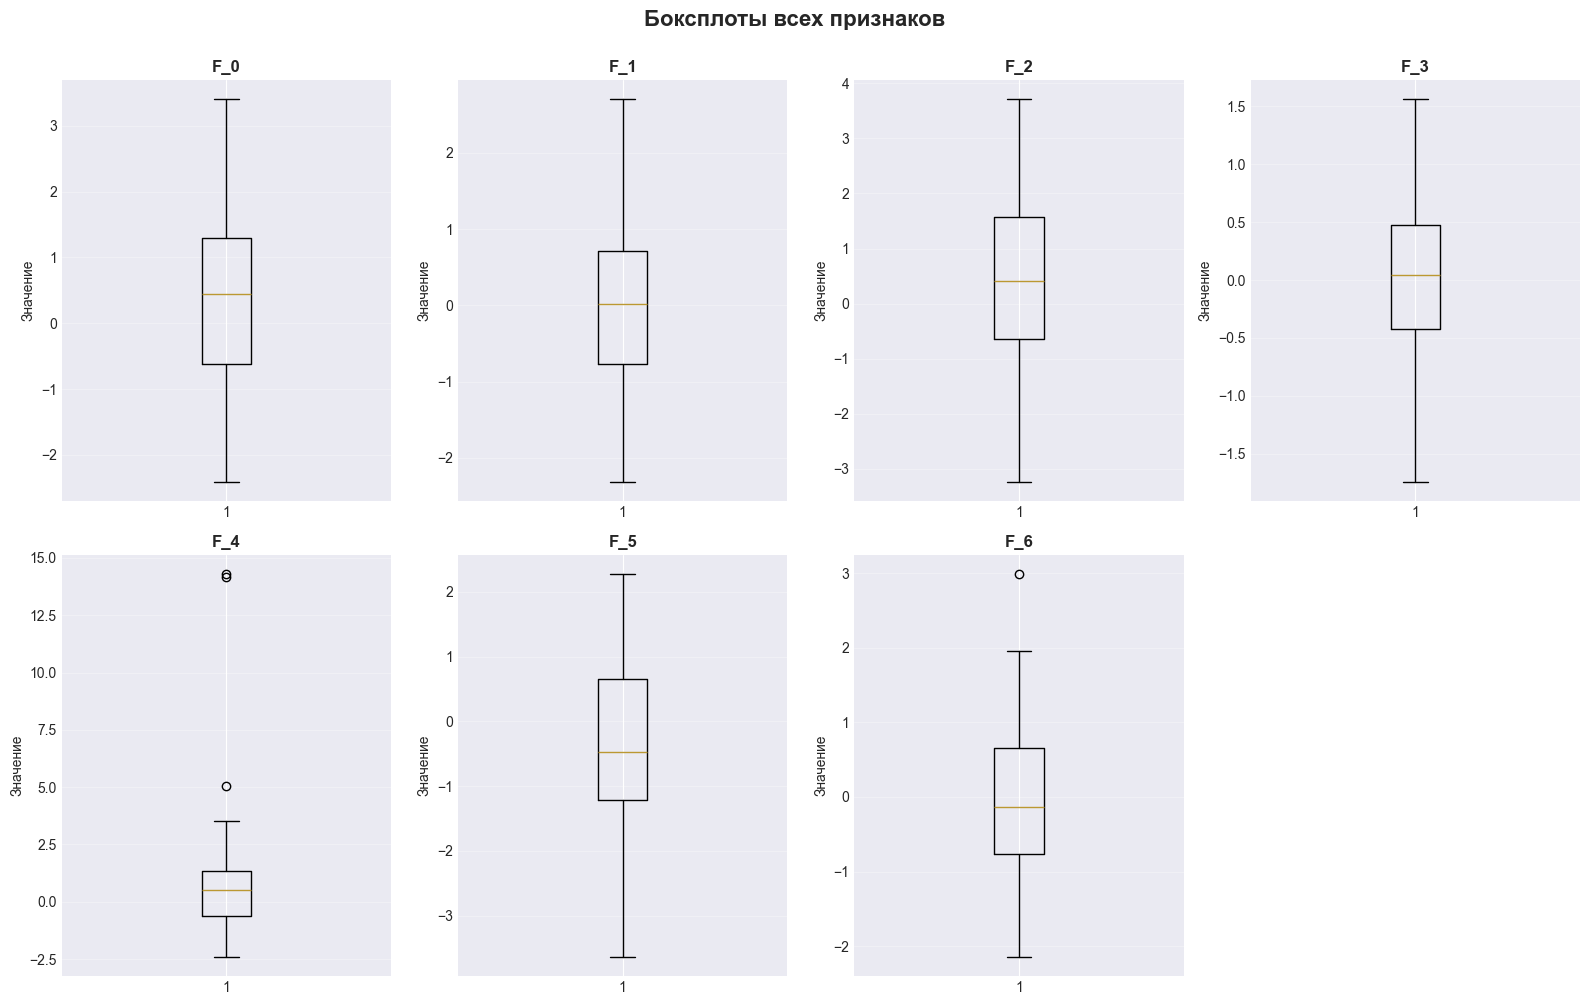

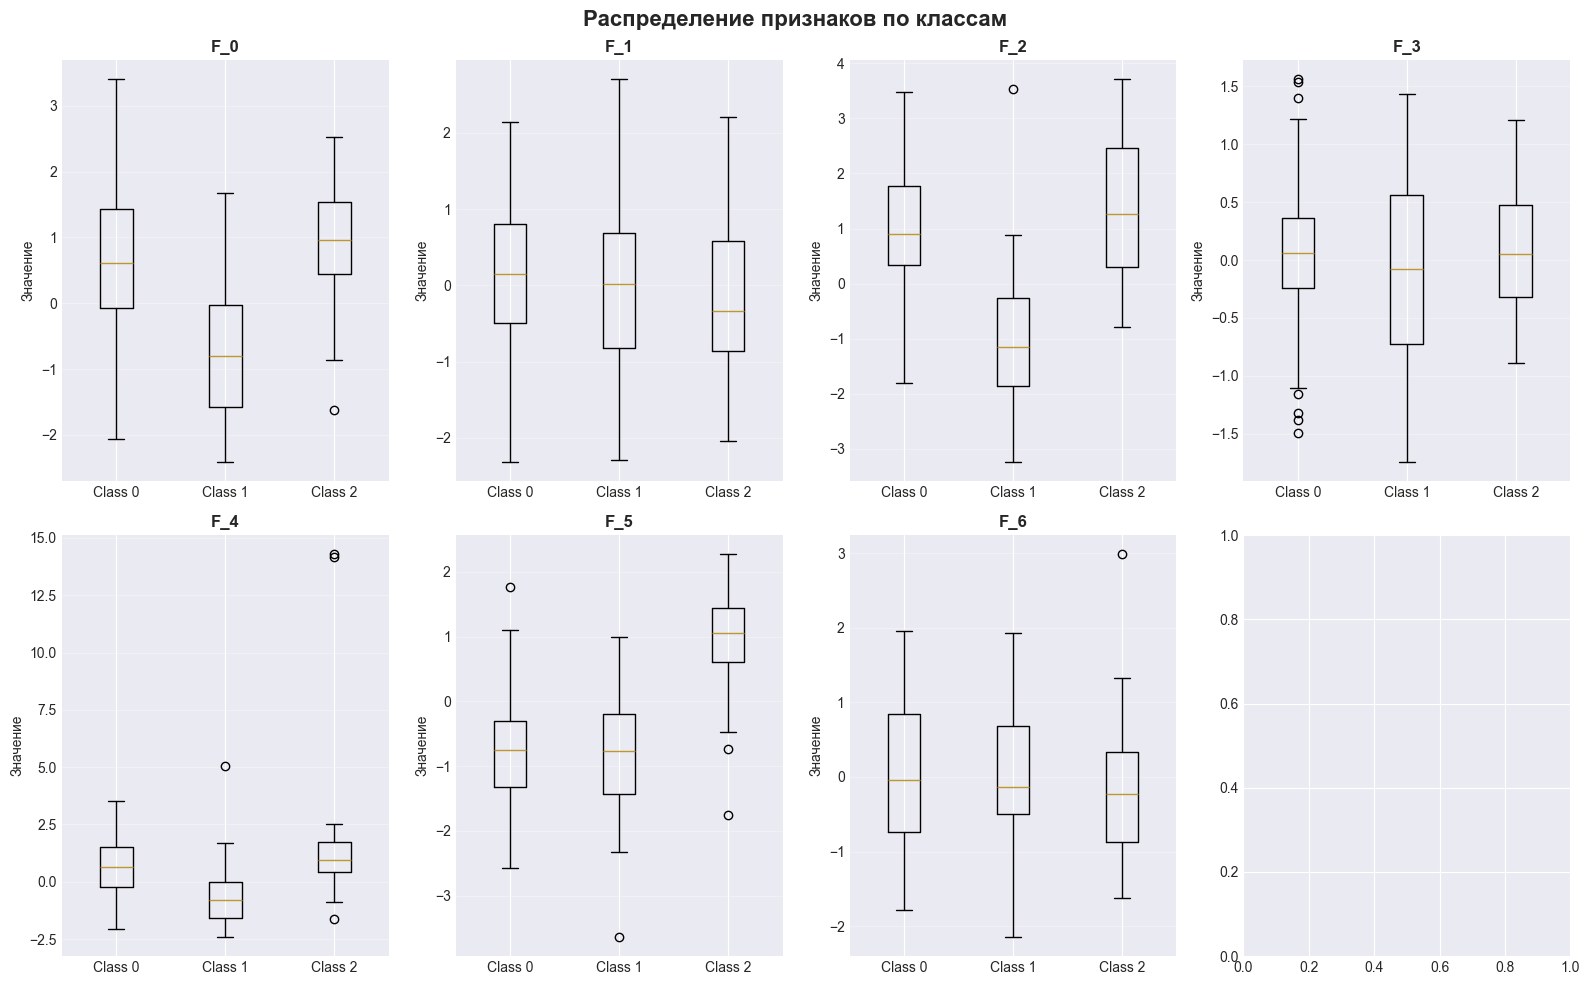

In [9]:
# Боксплоты для всех признаков
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(df_filled.columns):
    axes[idx].boxplot(df_filled[col], vert=True)
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].set_ylabel('Значение')

fig.delaxes(axes[-1])

# Боксплоты по классам
plt.suptitle("Боксплоты всех признаков", fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(df_filled.columns):
    if col != 'Class':
        class_data = [df_filled[df_filled['Class'] == cls][col].values 
                      for cls in sorted(df_filled['Class'].unique())]
        axes[idx].boxplot(class_data, labels=[f'Class {int(c)}' for c in sorted(df_filled['Class'].unique())])
        axes[idx].set_title(col, fontweight='bold')
        axes[idx].grid(axis='y', alpha=0.3)
        axes[idx].set_ylabel('Значение')

# Удаляем пустые ячейки
for idx in range(len(df_filled.columns), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle("Распределение признаков по классам", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


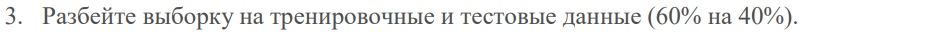

In [10]:
# Разбиение на признаки и целевую переменную
X = df_filled[df_columns].values
y = df_filled['Class'].values

# Нормализация признаков
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

# Разбиение 60% тренировочные, 40% тестовые
X_train, X_test, y_train, y_test = train_test_split(
    x_scaled, y, 
    test_size=0.4, 
    random_state=42, 
    stratify=y  # Сохранение распределения классов
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

# Проверка распределения классов
print("\nТренировочная выборка:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Класс {int(cls)}: {count} образцов ({count/len(y_train)*100:.1f}%)")

print("\nТестовая выборка:")
unique, counts = np.unique(y_test, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Класс {int(cls)}: {count} образцов ({count/len(y_test)*100:.1f}%)")

Размер обучающей выборки: (60, 7)
Размер тестовой выборки: (40, 7)

Тренировочная выборка:
  Класс 0: 22 образцов (36.7%)
  Класс 1: 19 образцов (31.7%)
  Класс 2: 19 образцов (31.7%)

Тестовая выборка:
  Класс 0: 14 образцов (35.0%)
  Класс 1: 13 образцов (32.5%)
  Класс 2: 13 образцов (32.5%)


In [11]:
# Статистика нормализации
print(f"\nСредние значения нормализованных признаков (обучение):")
print(np.mean(X_train, axis=0).round(4))
print(f"\nСтандартные отклонения нормализованных признаков (обучение):")
print(np.std(X_train, axis=0).round(4))


Средние значения нормализованных признаков (обучение):
[ 0.081  -0.0074  0.0284 -0.0392  0.0473  0.0237 -0.0897]

Стандартные отклонения нормализованных признаков (обучение):
[1.0348 0.922  1.0482 1.0494 0.9644 1.0403 0.8951]


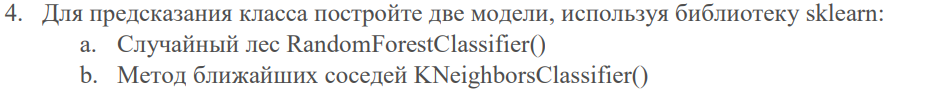

Случайный лес - f1-score (macro): 0.799457

Важность признаков (Random Forest):
  Feature  Importance
5     F_5    0.328082
2     F_2    0.214927
4     F_4    0.148345
0     F_0    0.114112
3     F_3    0.072611
1     F_1    0.069740
6     F_6    0.052182


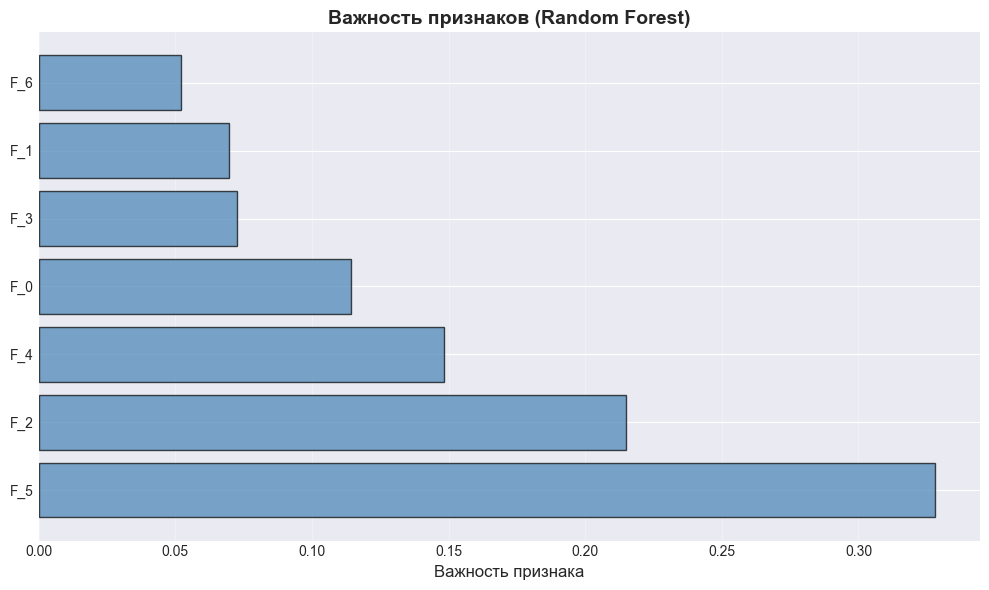

In [28]:
rf_model = RandomForestClassifier(
    n_estimators=30,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Предсказание
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)

rf_f1_macro = f1_score(y_test, y_pred_rf, average='macro')
print(f"Случайный лес - f1-score (macro): {rf_f1_macro:.6f}")

# Важность признаков
feature_importance = pd.DataFrame({
    'Feature': df_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nВажность признаков (Random Forest):")
print(feature_importance)

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance['Feature'], feature_importance['Importance'], 
        color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Важность признака', fontsize=12)
ax.set_title('Важность признаков (Random Forest)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
best_k = None
best_f1 = -1
k_scores = []

for k in range(3, 15):
    model = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='macro')
    k_scores.append((k,f1))

    if f1 > best_f1:
        best_f1 = f1
        best_k = k
    
    print(f"  K={k}: f1-score={f1:.6f}")

print(f"Оптимальное количество соседей: {best_k} c f10-score: {best_f1:.6f}")

# Создание и обучение модели
knn_model = KNeighborsClassifier(
    n_neighbors=best_k,
    weights='distance',
    metric='euclidean',
    algorithm='auto'
)

knn_model.fit(X_train, y_train)

# Предсказание
y_pred_knn = knn_model.predict(X_test)
y_pred_proba_knn = knn_model.predict_proba(X_test)

knn_f1_macro = f1_score(y_test, y_pred_knn, average='macro')
print(f"\nБлизжайшие соседи - f1-score (macro): {knn_f1_macro:.6f}")


  K=3: f1-score=0.774929
  K=4: f1-score=0.774929
  K=5: f1-score=0.774929
  K=6: f1-score=0.800176
  K=7: f1-score=0.775950
  K=8: f1-score=0.799295
  K=9: f1-score=0.799295
  K=10: f1-score=0.776367
  K=11: f1-score=0.775485
  K=12: f1-score=0.799295
  K=13: f1-score=0.776367
  K=14: f1-score=0.773810
Оптимальное количество соседей: 6 c f10-score: 0.800176

Близжайшие соседи - f1-score (macro): 0.800176


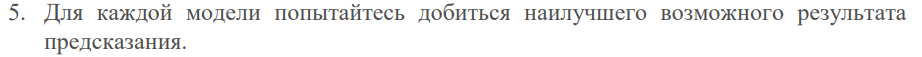

In [24]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("feat_sel", SelectFromModel(LogisticRegression(
        penalty="l1", solver="liblinear", C=1.0, random_state=42
    ))),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "feat_sel__estimator__C": [0.1, 1, 10],
    "knn__n_neighbors": [3,5,7,9,11],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(
    pipe, param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)
grid.fit(X_train, y_train)

knn_f1_macro_cv = grid.best_score_
print("Лучшие параметры:", grid.best_params_)
print("Лучший F1 macro (CV):", grid.best_score_)


Лучшие параметры: {'feat_sel__estimator__C': 0.1, 'knn__metric': 'euclidean', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
Лучший F1 macro (CV): 0.9325396825396826


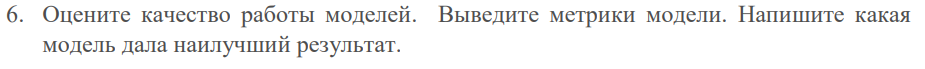

In [26]:
def choose_best_model(knn_result, rf_result):
    """Выбирает модель с лучшим f1-score"""
    if rf_result > knn_result:
        return 'Случайный лес', rf_result
    else:
        return 'Близжайшие соседи', knn_result

best_model_name, best_result = choose_best_model(knn_f1_macro_cv , rf_f1_macro)
print(f"Лучшая модель: {best_model_name}")
print(f"f1-score (macro): {best_result:.6f}")

# Выбираем предсказания лучшей модели
if best_model_name == 'Случайный лес':
    y_pred_best = y_pred_rf
    y_pred_proba_best = y_pred_proba_rf
    best_model = rf_model
else:
    y_pred_best = y_pred_knn
    y_pred_proba_best = y_pred_proba_knn
    best_model = knn_model


Лучшая модель: Близжайшие соседи
f1-score (macro): 0.932540


In [22]:
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    """Вычисляет и выводит все метрики качества"""
    
    accuracy = accuracy_score(y_true, y_pred)
    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    
    print(f"МОДЕЛЬ: {model_name}")
    print(f"Accuracy(доля верных ответов):     {accuracy:.6f}")
    print(f"Precision(точность):    {precision_macro:.6f}")
    print(f"Recall(полнота):       {recall_macro:.6f}")
    print(f"F1-score:     {f1_macro:.6f}")
    
    # Подробный отчет по классам
    print(f"\n{'Метрика':<15} {'Класс 0':<12} {'Класс 1':<12} {'Класс 2':<12}")
    print("-" * 51)
    
    precision_per_class = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall_per_class = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0)
    
    print(f"{'Precision':<16} {precision_per_class[0]:<12.6f} {precision_per_class[1]:<12.6f} {precision_per_class[2]:<12.6f}")
    print(f"{'Recall':<13}    {recall_per_class[0]:<12.6f} {recall_per_class[1]:<12.6f} {recall_per_class[2]:<12.6f}")
    print(f"{'F1-score':<15}  {f1_per_class[0]:<12.6f} {f1_per_class[1]:<12.6f} {f1_per_class[2]:<12.6f}")

    
    return {
        'accuracy': accuracy,
        'precision': precision_macro,
        'recall': recall_macro,
        'f1': f1_macro,
        'precision_per_class': precision_per_class,
        'recall_per_class': recall_per_class,
        'f1_per_class': f1_per_class
    }

# Оценка Random Forest
rf_metrics = evaluate_model(y_test, y_pred_rf, y_pred_proba_rf, 'Случайный лес')

# Оценка KNN
knn_metrics = evaluate_model(y_test, y_pred_knn, y_pred_proba_knn, 'Метод близжайших соседей')


МОДЕЛЬ: Случайный лес
Accuracy(доля верных ответов):     0.800000
Precision(точность):    0.811111
Recall(полнота):       0.800366
F1-score:     0.799457

Метрика         Класс 0      Класс 1      Класс 2     
---------------------------------------------------
Precision        0.733333     0.800000     0.900000    
Recall           0.785714     0.923077     0.692308    
F1-score         0.758621     0.857143     0.782609    
МОДЕЛЬ: Метод близжайших соседей
Accuracy(доля верных ответов):     0.800000
Precision(точность):    0.801587
Recall(полнота):       0.800366
F1-score:     0.800176

Метрика         Класс 0      Класс 1      Класс 2     
---------------------------------------------------
Precision        0.785714     0.785714     0.833333    
Recall           0.785714     0.846154     0.769231    
F1-score         0.785714     0.814815     0.800000    


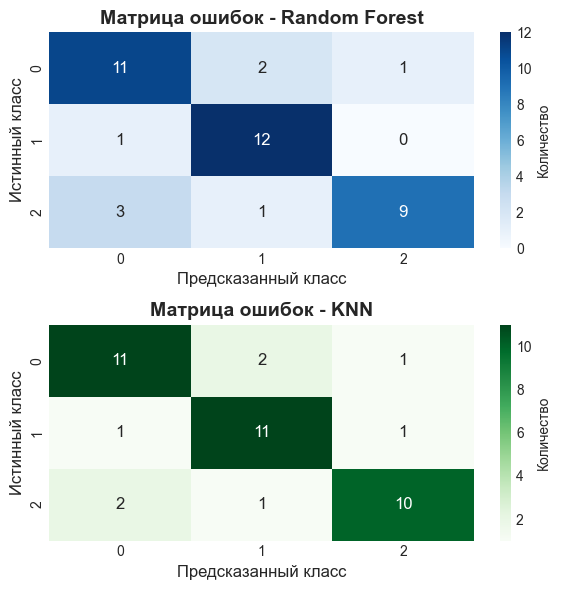

In [16]:
# Матрица ошибок для Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Матрица ошибок для KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Визуализация матриц ошибок
fig, axes = plt.subplots(2, 1, figsize=(6,6))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            cbar_kws={'label': 'Количество'}, annot_kws={'fontsize': 12})
axes[0].set_title('Матрица ошибок - Random Forest', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Предсказанный класс', fontsize=12)
axes[0].set_ylabel('Истинный класс', fontsize=12)

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            cbar_kws={'label': 'Количество'}, annot_kws={'fontsize': 12})
axes[1].set_title('Матрица ошибок - KNN', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Предсказанный класс', fontsize=12)
axes[1].set_ylabel('Истинный класс', fontsize=12)

plt.tight_layout()
plt.show()




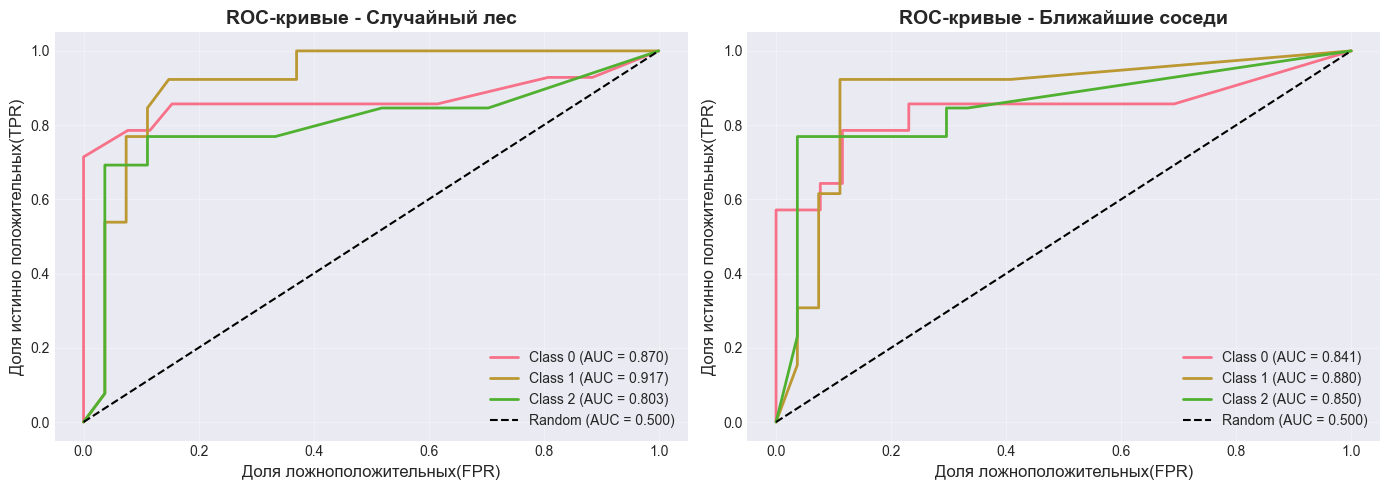

In [17]:
# Бинаризация целевой переменной
y_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
for i, class_name in enumerate(['Class 0', 'Class 1', 'Class 2']):
    fpr_rf, tpr_rf, _ = roc_curve(y_bin[:, i], y_pred_proba_rf[:, i])
    roc_auc_rf = roc_auc_score(y_bin[:, i], y_pred_proba_rf[:, i])
    axes[0].plot(fpr_rf, tpr_rf, label=f'{class_name} (AUC = {roc_auc_rf:.3f})', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)', linewidth=1.5)
axes[0].set_xlabel('Доля ложноположительных(FPR)', fontsize=12)
axes[0].set_ylabel('Доля истинно положительных(TPR)', fontsize=12)
axes[0].set_title('ROC-кривые - Случайный лес', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)

# KNN
for i, class_name in enumerate(['Class 0', 'Class 1', 'Class 2']):
    fpr_knn, tpr_knn, _ = roc_curve(y_bin[:, i], y_pred_proba_knn[:, i])
    roc_auc_knn = roc_auc_score(y_bin[:, i], y_pred_proba_knn[:, i])
    axes[1].plot(fpr_knn, tpr_knn, label=f'{class_name} (AUC = {roc_auc_knn:.3f})', linewidth=2)

axes[1].plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)', linewidth=1.5)
axes[1].set_xlabel('Доля ложноположительных(FPR)', fontsize=12)
axes[1].set_ylabel('Доля истинно положительных(TPR)', fontsize=12)
axes[1].set_title('ROC-кривые - Ближайшие соседи', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

